In [1]:
import gzip
import io
import json
import math
import os
import random
import re
import sys
import time
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import scipy.sparse as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("python :", sys.version.split()[0])
print("numpy  :", np.__version__)

python : 3.11.9
numpy  : 2.4.6


In [2]:
# ----------------------------- experiment configuration -----------------------------
CONFIG = {
    # dataset construction
    "sentences_per_language": 1000,   # required by the assignment
    "max_lines_to_scan": 40000,       # paragraphs streamed per language before giving up
    "min_chars": 20,                  # sentence quality filters
    "max_chars": 300,
    "min_words": 4,
    "split_ratio": (0.8, 0.1, 0.1),   # train : validation : test

    # TF-IDF
    "word_ngrams": (1, 2),            # word unigrams + bigrams
    "char_ngrams": (2, 3, 4),         # character 2/3/4-grams (word-boundary aware)
    "min_df": 3,                      # a feature must appear in >= min_df training sentences
    "max_features": {                 # per feature family, kept by descending document freq
        "w1": 100000,
        "w2": 100000,
        "c2": 50000,
        "c3": 150000,
        "c4": 250000,
    },

    # logistic regression
    "lr": 0.05,
    "epochs": 40,
    "batch_size": 2048,
    "l2": 1e-6,
    "patience": 6,                    # early stopping on validation macro-F1
}
CONFIG

{'sentences_per_language': 1000,
 'max_lines_to_scan': 40000,
 'min_chars': 20,
 'max_chars': 300,
 'min_words': 4,
 'split_ratio': (0.8, 0.1, 0.1),
 'word_ngrams': (1, 2),
 'char_ngrams': (2, 3, 4),
 'min_df': 3,
 'max_features': {'w1': 100000,
  'w2': 100000,
  'c2': 50000,
  'c3': 150000,
  'c4': 250000},
 'lr': 0.05,
 'epochs': 40,
 'batch_size': 2048,
 'l2': 1e-06,
 'patience': 6}

In [3]:
from huggingface_hub import HfApi, hf_hub_url

try:
    from huggingface_hub import get_token
except ImportError:  # older versions of huggingface_hub
    from huggingface_hub import HfFolder

    def get_token():
        return HfFolder.get_token()

REPO_ID = "ai4bharat/IndicCorpV2"
_FILE_RE = re.compile(r"(?:^|/)([A-Za-z]{2,4}(?:[_-][A-Za-z]{4})?)\.txt(\.gz)?$")


def discover_language_files(repo_id=REPO_ID):
    """Return {label: path-in-repo} for every monolingual text file in the repository."""
    files = HfApi().list_repo_files(repo_id, repo_type="dataset")
    found = {}
    for path in files:
        m = _FILE_RE.search(path)
        if not m:
            continue
        label = m.group(1)
        # if the same label shows up twice keep the shortest path (the top-level file)
        if label not in found or len(path) < len(found[label]):
            found[label] = path
    return dict(sorted(found.items()))


LANG_FILES = discover_language_files()
print("language files found in the repository:", len(LANG_FILES))
for label, path in LANG_FILES.items():
    print("  %-10s -> %s" % (label, path))

d:\SVNIT\Semester - 7\Introduction to Large Language Models\Practicals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


language files found in the repository: 23
  as         -> data/as.txt
  bd         -> data/bd.txt
  bn         -> data/bn.txt
  dg         -> data/dg.txt
  en         -> data/en.txt
  gom        -> data/gom.txt
  gu         -> data/gu.txt
  kha        -> data/kha.txt
  kn         -> data/kn.txt
  ks         -> data/ks.txt
  mai        -> data/mai.txt
  ml         -> data/ml.txt
  mni        -> data/mni.txt
  mr         -> data/mr.txt
  ne         -> data/ne.txt
  or         -> data/or.txt
  pa         -> data/pa.txt
  sa         -> data/sa.txt
  sat        -> data/sat.txt
  sd         -> data/sd.txt
  ta         -> data/ta.txt
  te         -> data/te.txt
  ur         -> data/ur.txt


In [4]:
import requests


def stream_lines(repo_path, max_lines, repo_id=REPO_ID, timeout=60):
    """Yield up to `max_lines` decoded lines from a file inside the HF dataset repo."""
    url = hf_hub_url(repo_id, repo_path, repo_type="dataset")
    token = get_token()
    headers = {"Authorization": "Bearer " + token} if token else {}
    with requests.get(url, headers=headers, stream=True, timeout=timeout) as resp:
        resp.raise_for_status()
        raw = resp.raw
        if repo_path.endswith(".gz"):
            raw = gzip.GzipFile(fileobj=raw)
        reader = io.TextIOWrapper(raw, encoding="utf-8", errors="ignore")
        for i, line in enumerate(reader):
            if i >= max_lines:
                break
            yield line

In [5]:
# sentence terminators used across the three script families in the corpus
DANDA = "।"           # Devanagari danda
DOUBLE_DANDA = "॥"    # Devanagari double danda
ARABIC_FULL_STOP = "۔"
ARABIC_QUESTION = "؟"
ELLIPSIS = "…"
IDEOGRAPHIC_STOP = "。"

HARD_STOPS = (DANDA + DOUBLE_DANDA + ARABIC_FULL_STOP + ARABIC_QUESTION
              + ELLIPSIS + IDEOGRAPHIC_STOP + "!?")

_HARD_SPLIT = re.compile(r"(?<=[" + re.escape(HARD_STOPS) + r"])\s+|\n+")
# a period is a sentence break only if it is not a decimal point and not an "A." style initial
_DOT_SPLIT = re.compile(r"(?<![A-Z]\.)(?<!\d\.)(?<=\.)\s+(?!\d)")
_WS = re.compile(r"\s+")
_URL = re.compile(r"https?://\S+|www\.\S+|\S+@\S+\.\S+")


def sentence_tokenize(paragraph):
    """Split one IndicCorp paragraph into a list of sentences."""
    paragraph = _URL.sub(" ", paragraph)
    sentences = []
    for chunk in _HARD_SPLIT.split(paragraph):
        if not chunk:
            continue
        for piece in _DOT_SPLIT.split(chunk):
            piece = _WS.sub(" ", piece).strip()
            if piece:
                sentences.append(piece)
    return sentences


# sanity check on a synthetic multi-script paragraph
_demo = (
    "પહેલું વાક્ય" + DANDA + " "
    + "यह दूसरा वाक्य" + DANDA + " "
    + "This costs 3.5 rupees. And this is the last one!"
)
for s in sentence_tokenize(_demo):
    print(repr(s))

'પહેલું વાક્ય।'
'यह दूसरा वाक्य।'
'This costs 3.5 rupees.'
'And this is the last one!'


In [6]:
_MARK_CATEGORIES = {"Mn", "Mc", "Me"}
_CHAR_CLASS_CACHE = {}


def is_word_char(ch):
    """Letter, digit or combining mark.

    `\\w` from Python's `re` is NOT usable here: Gujarati / Devanagari vowel signs such as
    U+0ACD are Unicode category `Mn`/`Mc`, and `str.isalnum()` reports those as False - so
    `\\w+` would tear every Indic word apart at its matras.
    """
    cached = _CHAR_CLASS_CACHE.get(ch)
    if cached is None:
        cached = ch.isalnum() or unicodedata.category(ch) in _MARK_CATEGORIES
        _CHAR_CLASS_CACHE[ch] = cached
    return cached


def word_tokenize(text):
    """Unicode-aware word tokenizer that keeps combining marks attached to their base letter."""
    tokens, buf = [], []
    for ch in text:
        if is_word_char(ch):
            buf.append(ch)
        elif buf:
            tokens.append("".join(buf))
            buf = []
    if buf:
        tokens.append("".join(buf))
    return tokens


def is_letterish(ch):
    cat = unicodedata.category(ch)
    return cat[0] == "L" or cat in _MARK_CATEGORIES


def acceptable_sentence(sentence, cfg=CONFIG):
    n = len(sentence)
    if n < cfg["min_chars"] or n > cfg["max_chars"]:
        return False
    words = word_tokenize(sentence)
    if len(words) < cfg["min_words"]:
        return False
    letters = sum(1 for ch in sentence if is_letterish(ch))
    return letters / n >= 0.6


print(acceptable_sentence("This is a perfectly ordinary English sentence for testing."))
print(acceptable_sentence("12 / 34 / 56 -- 78"))

True
False


In [7]:
def collect_language(label, repo_path, cfg=CONFIG, verbose=True):
    """Stream a language file and return `sentences_per_language` clean, unique sentences."""
    target = cfg["sentences_per_language"]
    seen, kept = set(), []
    t0 = time.time()
    try:
        for line in stream_lines(repo_path, cfg["max_lines_to_scan"]):
            for sentence in sentence_tokenize(line):
                if sentence in seen or not acceptable_sentence(sentence, cfg):
                    continue
                seen.add(sentence)
                kept.append(sentence)
                if len(kept) >= target:
                    raise StopIteration
    except StopIteration:
        pass
    except Exception as exc:  # a network hiccup on one language must not kill the whole run
        print("  !! %s: %s: %s" % (label, type(exc).__name__, exc))
    if verbose:
        print("  %-10s %5d sentences  (%5.1fs)" % (label, len(kept), time.time() - t0))
    return kept


RAW_PATH = os.path.join(DATA_DIR, "sentences.json")

if os.path.exists(RAW_PATH):
    with io.open(RAW_PATH, encoding="utf-8") as f:
        corpus = json.load(f)
    print("loaded cached corpus: %d languages" % len(corpus))
else:
    corpus = {}
    print("collecting sentences (streamed from the Hugging Face hub)...")
    for label, path in LANG_FILES.items():
        sentences = collect_language(label, path)
        if len(sentences) >= CONFIG["sentences_per_language"]:
            corpus[label] = sentences
        else:
            print("  -- dropping %s: only %d usable sentences" % (label, len(sentences)))
    with io.open(RAW_PATH, "w", encoding="utf-8") as f:
        json.dump(corpus, f, ensure_ascii=False)
    print("\nsaved -> " + RAW_PATH)

LABELS = sorted(corpus)
LABEL2ID = {lab: i for i, lab in enumerate(LABELS)}
n_lang, n_per = len(LABELS), CONFIG["sentences_per_language"]
print("\n%d languages x %d sentences = %d sentences" % (n_lang, n_per, n_lang * n_per))
print(LABELS)

loaded cached corpus: 23 languages

23 languages x 1000 sentences = 23000 sentences
['as', 'bd', 'bn', 'dg', 'en', 'gom', 'gu', 'kha', 'kn', 'ks', 'mai', 'ml', 'mni', 'mr', 'ne', 'or', 'pa', 'sa', 'sat', 'sd', 'ta', 'te', 'ur']


In [8]:
# a couple of examples, to eyeball the sentence tokenization
for label in LABELS[:5]:
    print("[%s] %s" % (label, corpus[label][0][:90]))

[as] ঘটনাৰ বিৱৰণি মতে বোকাকাতৰ কৈলাখাতত নিয়মিতভাৱে বহা জুৱাৰ আড্ডাত শুকুৰবাৰে অৰ্থাৎ ১৯ এপ্ৰিলৰ
[bd] बेबादि समावनो भारत हादोरनि सासे काबादि खेलानि फोरोंगिरि असन सांगबानआ आबादारि आयेनखौ मिरु स
[bn] নয়াদিল্লি: আজ ভ্যালেন্টাইনস ডে।
[dg] सालाना आरजी अनुदान (स्टेशनरी , यूनिफ़ार्म बगैरा ज्नेह् आकस्मिक खर्च गी कवर करने आस्तै )
[en] We start from where we left you last Friday and here is ayah 46 of Surah Zumar :


In [9]:
def stratified_split(corpus, ratio=CONFIG["split_ratio"], seed=SEED):
    rng = random.Random(seed)
    train, val, test = [], [], []
    for label in sorted(corpus):
        sentences = list(corpus[label])
        rng.shuffle(sentences)
        n = len(sentences)
        n_train = int(round(ratio[0] * n))
        n_val = int(round(ratio[1] * n))
        train += [(s, label) for s in sentences[:n_train]]
        val += [(s, label) for s in sentences[n_train:n_train + n_val]]
        test += [(s, label) for s in sentences[n_train + n_val:]]
    for part in (train, val, test):
        rng.shuffle(part)
    return train, val, test


train_pairs, val_pairs, test_pairs = stratified_split(corpus)

X_train_txt, y_train_lab = zip(*train_pairs)
X_val_txt, y_val_lab = zip(*val_pairs)
X_test_txt, y_test_lab = zip(*test_pairs)

y_train = np.array([LABEL2ID[l] for l in y_train_lab], dtype=np.int32)
y_val = np.array([LABEL2ID[l] for l in y_val_lab], dtype=np.int32)
y_test = np.array([LABEL2ID[l] for l in y_test_lab], dtype=np.int32)

print("train %6d   val %5d   test %5d" % (len(X_train_txt), len(X_val_txt), len(X_test_txt)))
balanced = (len(set(Counter(y_train_lab).values())) == 1
            and len(set(Counter(y_val_lab).values())) == 1
            and len(set(Counter(y_test_lab).values())) == 1)
print("per-language counts identical in every split:", balanced)
per_split = tuple(Counter(lab).most_common(1)[0][1]
                  for lab in (y_train_lab, y_val_lab, y_test_lab))
print("per language ->  train %d | val %d | test %d" % per_split)

train  18400   val  2300   test  2300
per-language counts identical in every split: True
per language ->  train 800 | val 100 | test 100


In [10]:
# Persist the splits - Assignment 2 reuses exactly this dataset.
def save_split(name, texts, labels):
    path = os.path.join(DATA_DIR, name + ".tsv")
    with io.open(path, "w", encoding="utf-8", newline="\n") as f:
        f.write("label\ttext\n")
        for t, l in zip(texts, labels):
            f.write(l + "\t" + t + "\n")
    print("saved %s  (%d rows)" % (path, len(texts)))


save_split("train", X_train_txt, y_train_lab)
save_split("val", X_val_txt, y_val_lab)
save_split("test", X_test_txt, y_test_lab)

with io.open(os.path.join(DATA_DIR, "labels.json"), "w", encoding="utf-8") as f:
    json.dump(LABELS, f, ensure_ascii=False, indent=1)

saved data\train.tsv  (18400 rows)
saved data\val.tsv  (2300 rows)
saved data\test.tsv  (2300 rows)


In [11]:
def extract_features(text, word_ngrams=CONFIG["word_ngrams"], char_ngrams=CONFIG["char_ngrams"]):
    """Return a Counter {feature -> raw count in this sentence}."""
    feats = Counter()
    words = word_tokenize(text.lower())

    # ---- word n-grams -------------------------------------------------------------
    lo, hi = word_ngrams
    for n in range(lo, hi + 1):
        prefix = "w%d:" % n
        if n == 1:
            for w in words:
                feats[prefix + w] += 1
        else:
            for i in range(len(words) - n + 1):
                feats[prefix + " ".join(words[i:i + n])] += 1

    # ---- character n-grams (word-boundary padded) ---------------------------------
    for word in words:
        padded = " " + word + " "
        L = len(padded)
        for n in char_ngrams:
            prefix = "c%d:" % n
            if L < n:
                continue
            for i in range(L - n + 1):
                feats[prefix + padded[i:i + n]] += 1
    return feats


demo_feats = extract_features("hello world")
print("features for 'hello world':", len(demo_feats))
print(sorted(k for k in demo_feats if k.startswith("w"))[:6])
print(sorted(k for k in demo_feats if k.startswith("c3:"))[:6])

features for 'hello world': 33
['w1:hello', 'w1:world', 'w2:hello world']
['c3: he', 'c3: wo', 'c3:ell', 'c3:hel', 'c3:ld ', 'c3:llo']


In [12]:
def l2_normalize(X):
    """Scale every row of a CSR matrix to unit L2 norm (returns a copy)."""
    X = X.tocsr(copy=True)
    norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1))).ravel()
    norms[norms == 0] = 1.0
    inv = np.repeat(1.0 / norms, np.diff(X.indptr))
    X.data = (X.data * inv).astype(X.dtype)
    return X


class TfIdfVectorizer:
    """From-scratch TF-IDF vectorizer over word and character n-grams.

    tf_scheme  : 'raw'      -> c(t, d)                                (unnormalized)
                 'len'      -> c(t, d) / (total words in d)           (Assignment 2)
                 'max'      -> c(t, d) / max_t' c(t', d)              (Assignment 2)
    idf_scheme : 'standard' -> log(N / df(t))                         (unnormalized)
                 'maxdf'    -> log(max_t' df(t') / df(t))             (Assignment 2)
    """

    def __init__(self, word_ngrams=CONFIG["word_ngrams"], char_ngrams=CONFIG["char_ngrams"],
                 min_df=CONFIG["min_df"], max_features=None,
                 tf_scheme="raw", idf_scheme="standard", norm="l2"):
        self.word_ngrams = word_ngrams
        self.char_ngrams = char_ngrams
        self.min_df = min_df
        self.max_features = max_features if max_features is not None else CONFIG["max_features"]
        self.tf_scheme = tf_scheme
        self.idf_scheme = idf_scheme
        self.norm = norm
        self.vocabulary_ = None
        self.idf_ = None

    # -------------------------------------------------------------- fitting
    def _count_docs(self, docs):
        return [extract_features(d, self.word_ngrams, self.char_ngrams) for d in docs]

    def fit(self, docs, counted=None, verbose=True):
        counted = counted if counted is not None else self._count_docs(docs)
        n_docs = len(counted)

        df = Counter()
        for c in counted:
            df.update(c.keys())
        if verbose:
            print("raw feature types: {:,}".format(len(df)))

        # keep features seen in at least `min_df` documents, then cap each family
        by_family = defaultdict(list)
        for feat, d in df.items():
            if d >= self.min_df:
                by_family[feat[:2]].append((d, feat))

        vocabulary, kept_df = {}, []
        for family in sorted(by_family):
            items = by_family[family]
            cap = self.max_features.get(family)
            if cap is not None and len(items) > cap:
                items.sort(key=lambda x: (-x[0], x[1]))
                items = items[:cap]
            for d, feat in sorted(items, key=lambda x: x[1]):
                vocabulary[feat] = len(vocabulary)
                kept_df.append(d)
            if verbose:
                print("  {}: {:>9,} features".format(family, len(items)))

        self.vocabulary_ = vocabulary
        df_arr = np.asarray(kept_df, dtype=np.float64)
        self.df_ = df_arr
        self.n_docs_ = n_docs

        if self.idf_scheme == "standard":
            self.idf_ = np.log(n_docs / df_arr)
        elif self.idf_scheme == "maxdf":
            # normalize the document frequency by the largest document frequency in the corpus
            self.idf_ = np.log(df_arr.max() / df_arr)
        else:
            raise ValueError("unknown idf_scheme %r" % (self.idf_scheme,))
        # a feature occurring in *every* document carries no information -> idf 0, keep it finite
        self.idf_ = np.maximum(self.idf_, 0.0)

        if verbose:
            print("vocabulary size: {:,}".format(len(vocabulary)))
        return self

    # -------------------------------------------------------------- transforming
    def _tf_scale(self, counter):
        """Return the multiplicative factor applied to every raw count of this document."""
        if self.tf_scheme == "raw":
            return 1.0
        if self.tf_scheme == "len":
            # total number of *words* in the sentence (the word-unigram counts sum to that)
            total = sum(v for k, v in counter.items() if k.startswith("w1:"))
            return 1.0 / total if total else 1.0
        if self.tf_scheme == "max":
            # frequency of the most frequent word in the sentence
            top = max((v for k, v in counter.items() if k.startswith("w1:")), default=0)
            return 1.0 / top if top else 1.0
        raise ValueError("unknown tf_scheme %r" % (self.tf_scheme,))

    def transform(self, docs, counted=None, dtype=np.float32):
        if self.vocabulary_ is None:
            raise RuntimeError("call fit() first")
        counted = counted if counted is not None else self._count_docs(docs)
        vocab, idf = self.vocabulary_, self.idf_

        indptr, indices, data = [0], [], []
        for counter in counted:
            scale = self._tf_scale(counter)
            for feat, count in counter.items():
                j = vocab.get(feat)
                if j is None:  # unseen at training time -> ignored
                    continue
                indices.append(j)
                data.append(count * scale * idf[j])
            indptr.append(len(indices))

        X = sp.csr_matrix(
            (np.asarray(data, dtype=dtype),
             np.asarray(indices, dtype=np.int32),
             np.asarray(indptr, dtype=np.int64)),
            shape=(len(counted), len(vocab)),
        )
        X.sum_duplicates()
        if self.norm == "l2":
            X = l2_normalize(X)
        return X

    def fit_transform(self, docs, counted=None, verbose=True):
        counted = counted if counted is not None else self._count_docs(docs)
        self.fit(docs, counted=counted, verbose=verbose)
        return self.transform(docs, counted=counted)

In [13]:
# Counting the n-grams is the expensive part, so do it once and reuse it everywhere
# (Assignment 2 re-weights these *same* counts six different ways).
t0 = time.time()
counts_train = [extract_features(t) for t in X_train_txt]
counts_val = [extract_features(t) for t in X_val_txt]
counts_test = [extract_features(t) for t in X_test_txt]
print("n-gram counting done in %.1fs" % (time.time() - t0))
print("avg features per sentence:", round(float(np.mean([len(c) for c in counts_train])), 1))

n-gram counting done in 4.1s
avg features per sentence: 217.4


In [14]:
t0 = time.time()
vectorizer = TfIdfVectorizer(tf_scheme="raw", idf_scheme="standard")
X_train = vectorizer.fit_transform(X_train_txt, counted=counts_train)
X_val = vectorizer.transform(X_val_txt, counted=counts_val)
X_test = vectorizer.transform(X_test_txt, counted=counts_test)
print("\nvectorized in %.1fs" % (time.time() - t0))
print("X_train", X_train.shape, "nnz={:,}".format(X_train.nnz),
      "density=%.2e" % (X_train.nnz / float(X_train.shape[0] * X_train.shape[1])))
print("X_val  ", X_val.shape)
print("X_test ", X_test.shape)

raw feature types: 693,644
  c2:    15,070 features
  c3:    55,382 features
  c4:    75,379 features
  w1:    16,072 features
  w2:     6,031 features
vocabulary size: 167,934

vectorized in 5.9s
X_train (18400, 167934) nnz=3,392,312 density=1.10e-03
X_val   (2300, 167934)
X_test  (2300, 167934)


In [15]:
class SoftmaxRegression:
    def __init__(self, n_features, n_classes, lr=CONFIG["lr"], l2=CONFIG["l2"],
                 batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
                 patience=CONFIG["patience"], seed=SEED):
        self.n_features, self.n_classes = n_features, n_classes
        self.lr, self.l2 = lr, l2
        self.batch_size, self.epochs, self.patience = batch_size, epochs, patience
        self.W = np.zeros((n_features, n_classes), dtype=np.float32)
        self.b = np.zeros(n_classes, dtype=np.float32)
        self.rng = np.random.RandomState(seed)
        self.history_ = []

    # ------------------------------------------------------------------ maths
    @staticmethod
    def _softmax(scores):
        scores = scores - scores.max(axis=1, keepdims=True)   # numerical stability
        np.exp(scores, out=scores)
        scores /= scores.sum(axis=1, keepdims=True)
        return scores

    def decision_function(self, X):
        return np.asarray(X @ self.W) + self.b

    def predict_proba(self, X):
        return self._softmax(self.decision_function(X).astype(np.float64))

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)

    def loss(self, X, y):
        P = self.predict_proba(X)
        nll = -np.log(np.clip(P[np.arange(len(y)), y], 1e-12, None)).mean()
        return float(nll + 0.5 * self.l2 * float((self.W ** 2).sum()))

    # ------------------------------------------------------------------ fitting
    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        n = X.shape[0]
        mW = np.zeros_like(self.W); vW = np.zeros_like(self.W)
        mb = np.zeros_like(self.b); vb = np.zeros_like(self.b)
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        step = 0
        best_score, best_state, stale = -1.0, None, 0

        for epoch in range(1, self.epochs + 1):
            order = self.rng.permutation(n)
            t0 = time.time()
            for start in range(0, n, self.batch_size):
                idx = order[start:start + self.batch_size]
                Xb, yb = X[idx], y[idx]
                B = Xb.shape[0]

                P = self._softmax(self.decision_function(Xb).astype(np.float64))
                P[np.arange(B), yb] -= 1.0          # P - Y
                P /= B

                gW = np.asarray(Xb.T @ P, dtype=np.float32)
                gW += self.l2 * self.W
                gb = P.sum(axis=0).astype(np.float32)

                step += 1
                bc1 = 1.0 - beta1 ** step
                bc2 = 1.0 - beta2 ** step
                mW *= beta1; mW += (1 - beta1) * gW
                vW *= beta2; vW += (1 - beta2) * (gW * gW)
                self.W -= self.lr * (mW / bc1) / (np.sqrt(vW / bc2) + eps)
                mb *= beta1; mb += (1 - beta1) * gb
                vb *= beta2; vb += (1 - beta2) * (gb * gb)
                self.b -= self.lr * (mb / bc1) / (np.sqrt(vb / bc2) + eps)

            record = {"epoch": epoch, "train_loss": self.loss(X, y), "sec": time.time() - t0}
            if X_val is not None:
                pred = self.predict(X_val)
                record["val_macro_f1"] = macro_f1(y_val, pred, self.n_classes)
                record["val_acc"] = accuracy(y_val, pred)
            self.history_.append(record)

            if verbose:
                msg = "epoch %3d  loss %.4f" % (epoch, record["train_loss"])
                if X_val is not None:
                    msg += "  val_acc %.4f  val_macroF1 %.4f" % (record["val_acc"],
                                                                 record["val_macro_f1"])
                print(msg + "  (%.1fs)" % record["sec"])

            if X_val is not None:
                if record["val_macro_f1"] > best_score + 1e-5:
                    best_score, stale = record["val_macro_f1"], 0
                    best_state = (self.W.copy(), self.b.copy())
                else:
                    stale += 1
                    if stale >= self.patience:
                        if verbose:
                            print("early stopping at epoch %d (best val macro-F1 %.4f)" % (
                                epoch, best_score))
                        break
        if best_state is not None:
            self.W, self.b = best_state
        return self

In [16]:
def confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    np.add.at(cm, (np.asarray(y_true), np.asarray(y_pred)), 1)
    return cm


def prf_per_class(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, n_classes)
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return precision, recall, f1, cm.sum(axis=1)


def macro_f1(y_true, y_pred, n_classes):
    return float(prf_per_class(y_true, y_pred, n_classes)[2].mean())


def accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def classification_report(y_true, y_pred, labels):
    p, r, f, support = prf_per_class(y_true, y_pred, len(labels))
    width = max(len(l) for l in labels) + 2
    head = "%-*s%8s%8s%8s%9s" % (width, "language", "prec", "recall", "f1", "support")
    lines = [head, "-" * (width + 33)]
    for i, lab in enumerate(labels):
        lines.append("%-*s%8.4f%8.4f%8.4f%9d" % (width, lab, p[i], r[i], f[i], support[i]))
    lines.append("-" * (width + 33))
    lines.append("%-*s%8.4f%8.4f%8.4f%9d" % (width, "macro avg", p.mean(), r.mean(), f.mean(),
                                             support.sum()))
    lines.append("%-*s%8.4f" % (width, "accuracy", accuracy(y_true, y_pred)))
    return "\n".join(lines)


# sanity check of the metric implementation on a tiny hand-computable example
_yt = np.array([0, 0, 1, 1, 2])
_yp = np.array([0, 1, 1, 1, 2])
# class0: P=1/1, R=1/2, F1=0.6667 | class1: P=2/3, R=1, F1=0.8 | class2: P=R=F1=1
print("macro-F1 (expected 0.8222):", round(macro_f1(_yt, _yp, 3), 4))

macro-F1 (expected 0.8222): 0.8222


In [17]:
model = SoftmaxRegression(n_features=X_train.shape[1], n_classes=len(LABELS))
t0 = time.time()
model.fit(X_train, y_train, X_val, y_val)
print("\ntotal training time: %.1fs" % (time.time() - t0))

epoch   1  loss 0.3073  val_acc 0.9357  val_macroF1 0.9356  (1.1s)
epoch   2  loss 0.2478  val_acc 0.9457  val_macroF1 0.9461  (1.1s)
epoch   3  loss 0.1888  val_acc 0.9452  val_macroF1 0.9456  (1.1s)
epoch   4  loss 0.1412  val_acc 0.9470  val_macroF1 0.9472  (1.2s)
epoch   5  loss 0.1121  val_acc 0.9435  val_macroF1 0.9438  (1.1s)
epoch   6  loss 0.0951  val_acc 0.9448  val_macroF1 0.9453  (1.1s)
epoch   7  loss 0.0849  val_acc 0.9430  val_macroF1 0.9434  (1.1s)
epoch   8  loss 0.0785  val_acc 0.9448  val_macroF1 0.9452  (1.1s)
epoch   9  loss 0.0741  val_acc 0.9439  val_macroF1 0.9443  (1.5s)
epoch  10  loss 0.0709  val_acc 0.9452  val_macroF1 0.9457  (1.0s)
early stopping at epoch 10 (best val macro-F1 0.9472)

total training time: 11.5s


In [18]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("=" * 60)
print("VALIDATION")
print("=" * 60)
print("accuracy  : %.4f" % accuracy(y_val, val_pred))
print("macro-F1  : %.4f" % macro_f1(y_val, val_pred, len(LABELS)))

print()
print("=" * 60)
print("TEST")
print("=" * 60)
print("accuracy  : %.4f" % accuracy(y_test, test_pred))
print("macro-F1  : %.4f" % macro_f1(y_test, test_pred, len(LABELS)))

VALIDATION
accuracy  : 0.9470
macro-F1  : 0.9472

TEST
accuracy  : 0.9465
macro-F1  : 0.9465


In [19]:
print(classification_report(y_test, test_pred, LABELS))

language    prec  recall      f1  support
--------------------------------------
as     1.0000  0.9900  0.9950      100
bd     0.9800  0.9800  0.9800      100
bn     0.9804  1.0000  0.9901      100
dg     0.9700  0.9700  0.9700      100
en     0.7041  0.6900  0.6970      100
gom    0.7629  0.7400  0.7513      100
gu     1.0000  1.0000  1.0000      100
kha    0.6759  0.7300  0.7019      100
kn     0.9901  1.0000  0.9950      100
ks     1.0000  0.9800  0.9899      100
mai    0.9703  0.9800  0.9751      100
ml     1.0000  1.0000  1.0000      100
mni    1.0000  0.9800  0.9899      100
mr     0.8000  0.7600  0.7795      100
ne     0.9900  0.9900  0.9900      100
or     1.0000  1.0000  1.0000      100
pa     1.0000  1.0000  1.0000      100
sa     0.9612  0.9900  0.9754      100
sat    1.0000  1.0000  1.0000      100
sd     1.0000  1.0000  1.0000      100
ta     1.0000  0.9900  0.9950      100
te     1.0000  1.0000  1.0000      100
ur     0.9901  1.0000  0.9950      100
----------------------

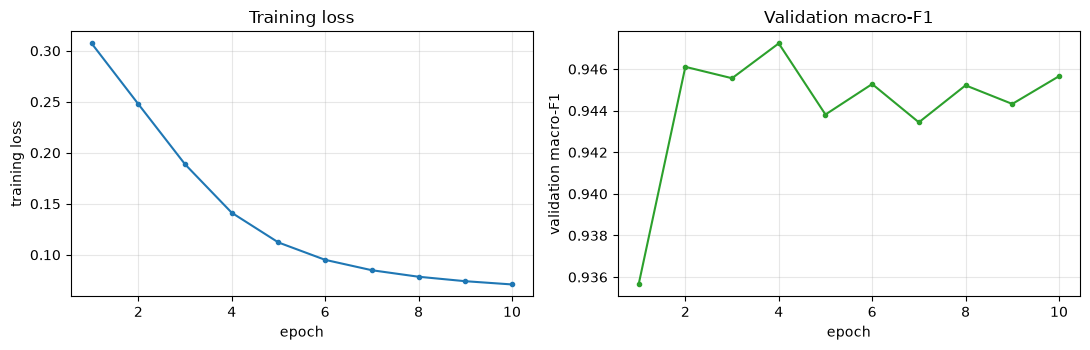

In [20]:
import matplotlib.pyplot as plt

hist = model.history_
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot([h["epoch"] for h in hist], [h["train_loss"] for h in hist], marker="o", ms=3)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss"); ax[0].set_title("Training loss")
ax[0].grid(alpha=.3)
if "val_macro_f1" in hist[0]:
    ax[1].plot([h["epoch"] for h in hist], [h["val_macro_f1"] for h in hist],
               marker="o", ms=3, color="tab:green")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation macro-F1")
    ax[1].set_title("Validation macro-F1"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

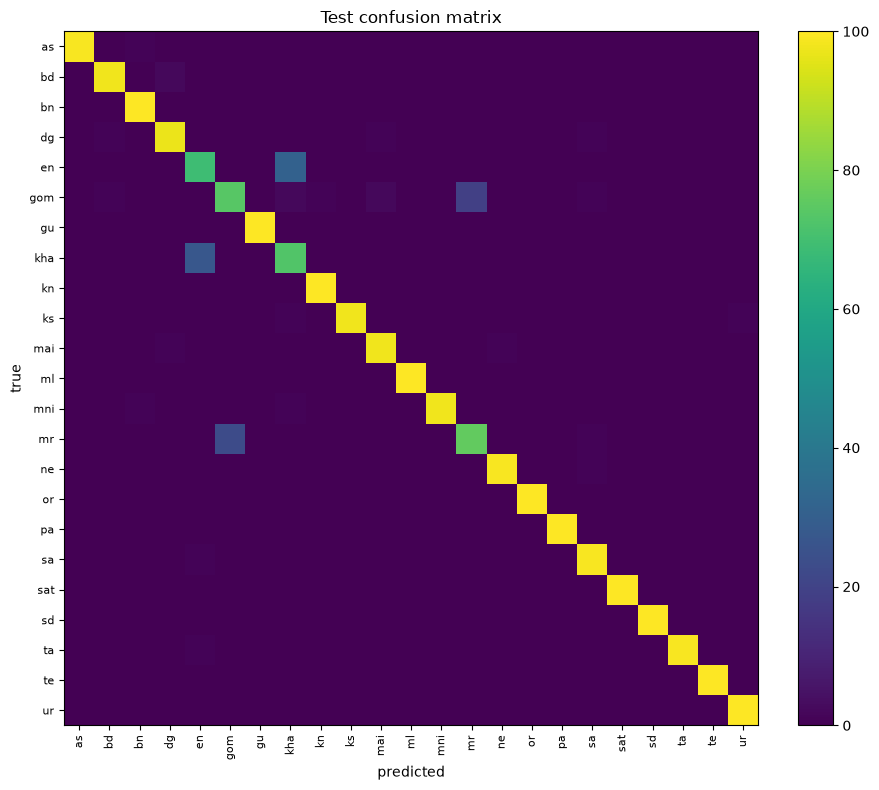

In [21]:
cm = confusion_matrix(y_test, test_pred, len(LABELS))
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="viridis")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=90, fontsize=8)
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Test confusion matrix")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

In [22]:
# Which language pairs are actually being confused?
cm = confusion_matrix(y_test, test_pred, len(LABELS))
pairs = []
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        if i != j and cm[i, j] > 0:
            pairs.append((int(cm[i, j]), LABELS[i], LABELS[j]))
pairs.sort(reverse=True)
print("most frequent confusions (true -> predicted):")
for count, true_lab, pred_lab in pairs[:15]:
    print("  %3d  %-10s -> %s" % (count, true_lab, pred_lab))
if not pairs:
    print("  none - the test set is classified perfectly")

most frequent confusions (true -> predicted):
   31  en         -> kha
   27  kha        -> en
   23  mr         -> gom
   19  gom        -> mr
    2  gom        -> mai
    2  gom        -> kha
    2  bd         -> dg
    1  ta         -> en
    1  sa         -> en
    1  ne         -> sa
    1  mr         -> sa
    1  mni        -> kha
    1  mni        -> bn
    1  mai        -> ne
    1  mai        -> dg


In [23]:
inv_vocab = {v: k for k, v in vectorizer.vocabulary_.items()}
for c, lab in enumerate(LABELS[:6]):
    top = np.argsort(-model.W[:, c])[:8]
    print("%-10s " % lab + "  ".join(repr(inv_vocab[j]) for j in top))

as         'c2:েৰ'  'c2:িহ'  'c4:নাম '  'c3:পুৰ'  'c3:ধাৰ'  'c4:নাই '  'c3:ষাৰ'  'c4:সকলো'
bd         'w1:का'  'c4: का '  'c3: को'  'w2:के साथ'  'c4:में '  'w1:को'  'c4: को '  'c3:में'
bn         'c4:গুলি'  'c4:াদের'  'c3: এখ'  'c2:এখ'  'c2:এল'  'c3:াদে'  'c3:যাব'  'c3:থা '
dg         'c2: औ'  'c4:िक्ख'  'c2:ऐ '  'c3: ऐ '  'w1:ऐ'  'c3:दिक'  'c4:दिक्'  'c4: दिक'
en         'c4:end '  'c3:aso'  'c3:chr'  'c4:ite '  'c4: rai'  'c4: fri'  'c3:mpi'  'c3:vil'
gom        'c2:tt'  'c2:ुन'  'c2:ेन'  'w1:हा'  'c4: हा '  'c3: मध'  'c4: ना '  'w1:ना'


In [24]:
RUN_ABLATION = True   # set to False to skip (each variant retrains the classifier)

if RUN_ABLATION:
    ablations = {
        "word 1-2 grams only": dict(word_ngrams=(1, 2), char_ngrams=()),
        "char 2-4 grams only": dict(word_ngrams=(1, 0), char_ngrams=(2, 3, 4)),
        "word + char (full)": dict(word_ngrams=(1, 2), char_ngrams=(2, 3, 4)),
    }
    ablation_results = {}
    for name, kwargs in ablations.items():
        print("\n--- %s ---" % name)
        counts_tr = [extract_features(t, **kwargs) for t in X_train_txt]
        counts_va = [extract_features(t, **kwargs) for t in X_val_txt]
        counts_te = [extract_features(t, **kwargs) for t in X_test_txt]
        vec = TfIdfVectorizer(**kwargs)
        Xtr = vec.fit_transform(X_train_txt, counted=counts_tr, verbose=False)
        Xva = vec.transform(X_val_txt, counted=counts_va)
        Xte = vec.transform(X_test_txt, counted=counts_te)
        clf = SoftmaxRegression(Xtr.shape[1], len(LABELS)).fit(
            Xtr, y_train, Xva, y_val, verbose=False)
        f1 = macro_f1(y_test, clf.predict(Xte), len(LABELS))
        ablation_results[name] = (Xtr.shape[1], f1)
        print("features {:>8,}   test macro-F1 {:.4f}".format(Xtr.shape[1], f1))

    print("\n%-24s%12s%16s" % ("feature set", "#features", "test macro-F1"))
    print("-" * 52)
    for name, (nf, f1) in ablation_results.items():
        print("{:<24}{:>12,}{:>16.4f}".format(name, nf, f1))


--- word 1-2 grams only ---
features   22,103   test macro-F1 0.9123

--- char 2-4 grams only ---
features  145,831   test macro-F1 0.9435

--- word + char (full) ---
features  167,934   test macro-F1 0.9465

feature set                #features   test macro-F1
----------------------------------------------------
word 1-2 grams only           22,103          0.9123
char 2-4 grams only          145,831          0.9435
word + char (full)           167,934          0.9465
